In [53]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import plotly.graph_objects as go
from scipy.integrate import trapezoid

import sys
sys.path.append("../")
from src.preprocessing import weigh_norm_densities, align_densities, df_to_densities, fit_kde_model
from src.transformations import ( 
                            mLQDT,
                            obtain_densities_from_lqd,
                            dens2lqd,
                            lqd2dens
                            )
                            

# Normal

In [105]:
mu = 0
sigma = 2
n = 256
normal_sample = np.random.normal(loc=mu, scale=sigma, size=n)
grid = np.linspace(normal_sample.min(), normal_sample.max(), n)

params = {'kernel': 'gaussian', 'bandwidth': 'scott'}
kde, density = fit_kde_model(normal_sample, params)

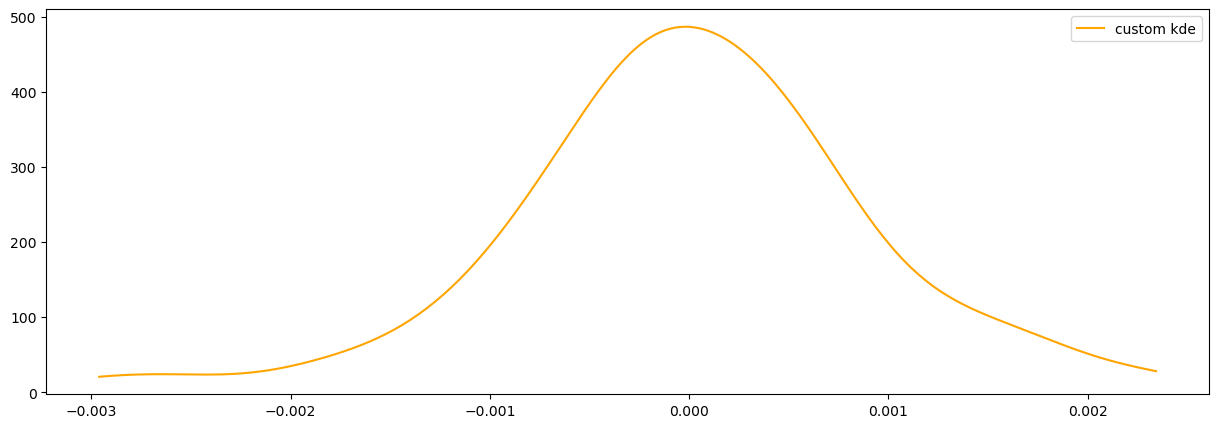

In [64]:
plt.figure(figsize=(15,5))

# sns.histplot(normal_sample, kde=True)
# sns.kdeplot(normal_sample, label="sns_kde")
sns.lineplot(x=kde.grid, y=density, color="orange", label="custom kde")

plt.show()

In [65]:
lqd_grid = np.linspace(0,1,n)
t0_ = kde.grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


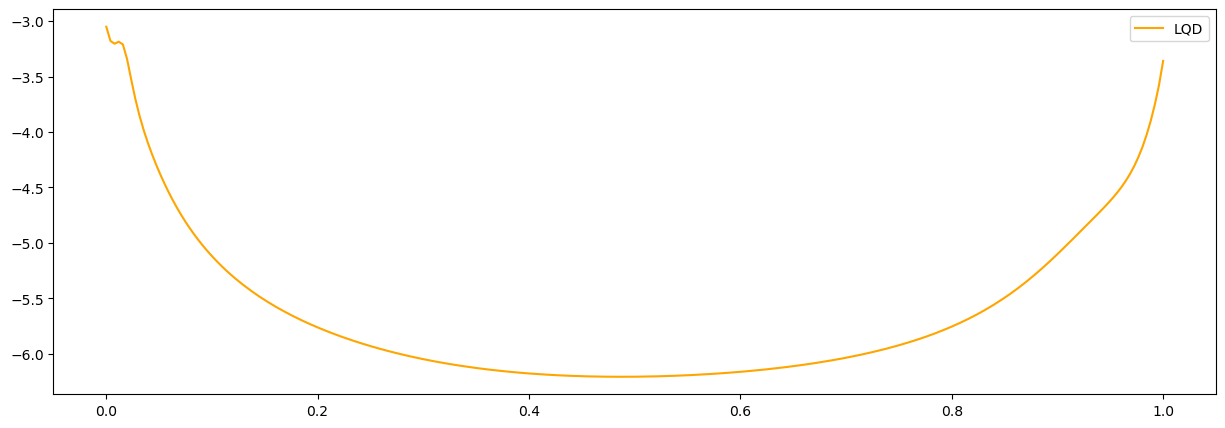

In [66]:
plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [67]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

c not in lqdSup — resetting to closest value.


In [68]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

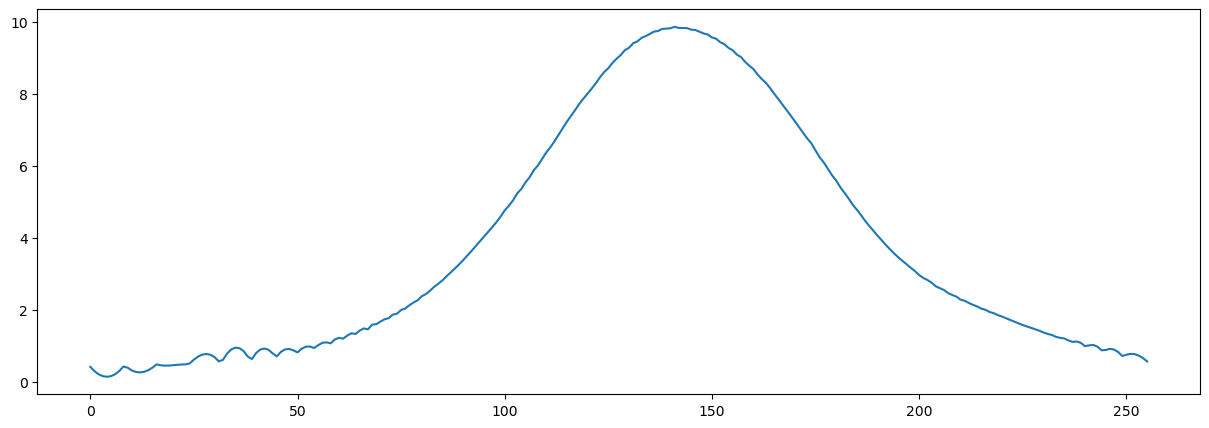

In [69]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

# Empiral density

In [2]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")
df.head()

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:00:00,0.000011,-0.000372,-0.000035,0.007233,-0.001305,-0.000459,0.002388,0.002212,-0.008001,-0.000824,...,-0.000957,-0.002307,-0.003734,-0.005020,-0.001139,-0.000255,0.002339,0.004176,-0.000224,-0.000238
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004


In [3]:
i = 10
t = df.columns[i]
n = 256

Z_t = df.loc[:, t]
params = {'kernel': 't_student', "df": 2, 'bandwidth': 'scott'}
# params = {"kernel": "t_student", "bandwidth": "scott", "df": 2, "adaptive": True}

## Local grid

In [4]:
grid = np.linspace(Z_t.min(), Z_t.max().max(), n)

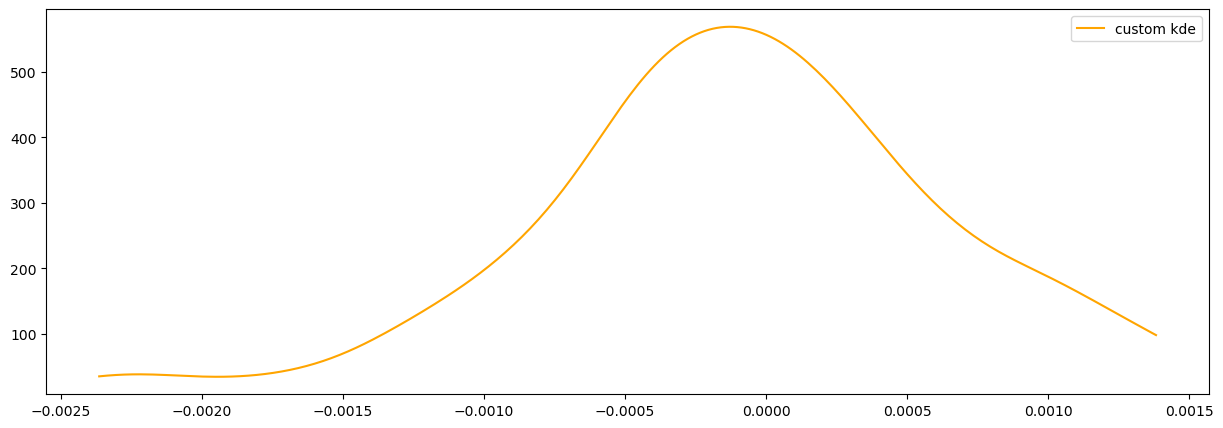

In [135]:
kde, density = fit_kde_model(Z_t, params)

plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


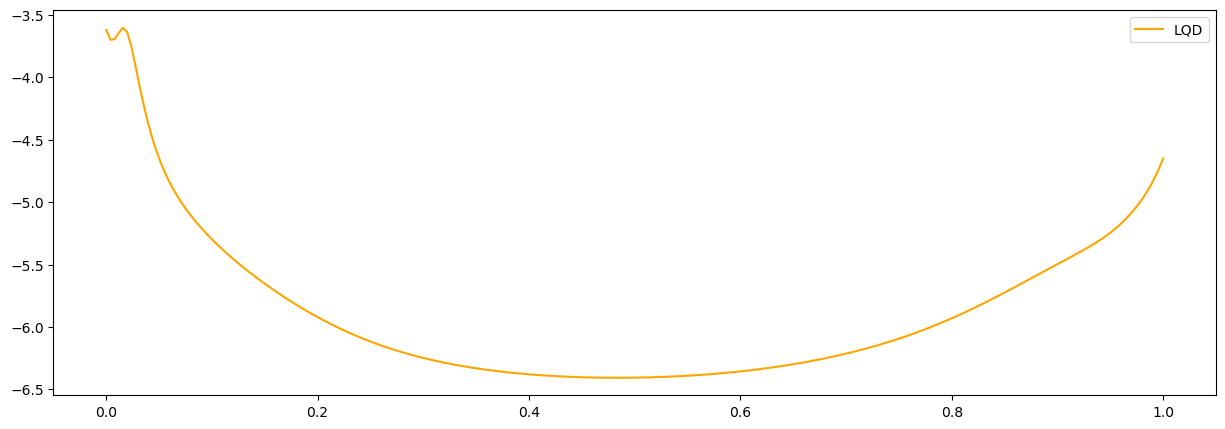

In [136]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(kde.grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [137]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, dSup=kde.grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=kde.grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

c not in lqdSup — resetting to closest value.


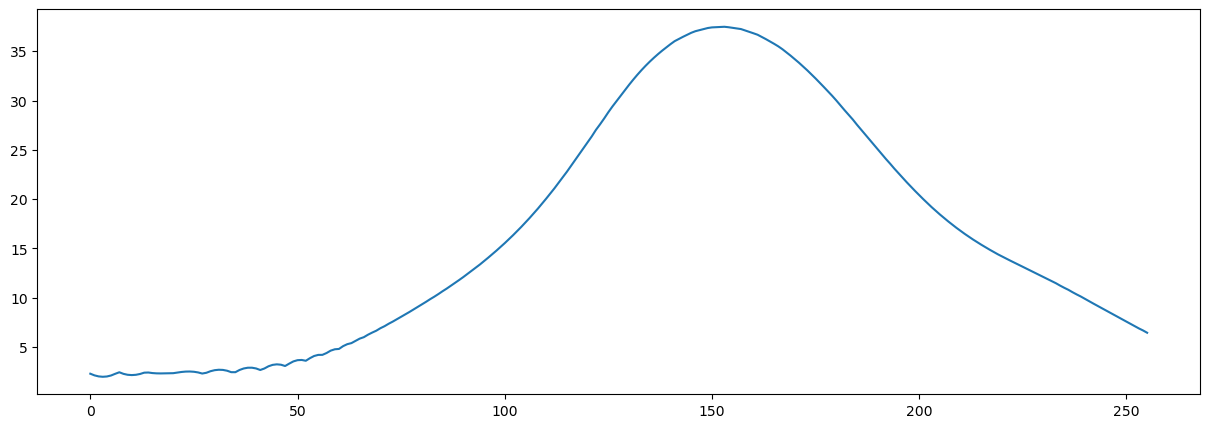

In [138]:
plt.figure(figsize=(15,5))

plt.plot(dens - density)

plt.show()

## Global grid

In [54]:
grid = np.linspace(df.min().min(), df.max().max(), n)

In [55]:
kde, density = fit_kde_model(Z_t, params, grid=grid)
# print(trapezoid(density/trapezoid(density, kde.grid), kde.grid))

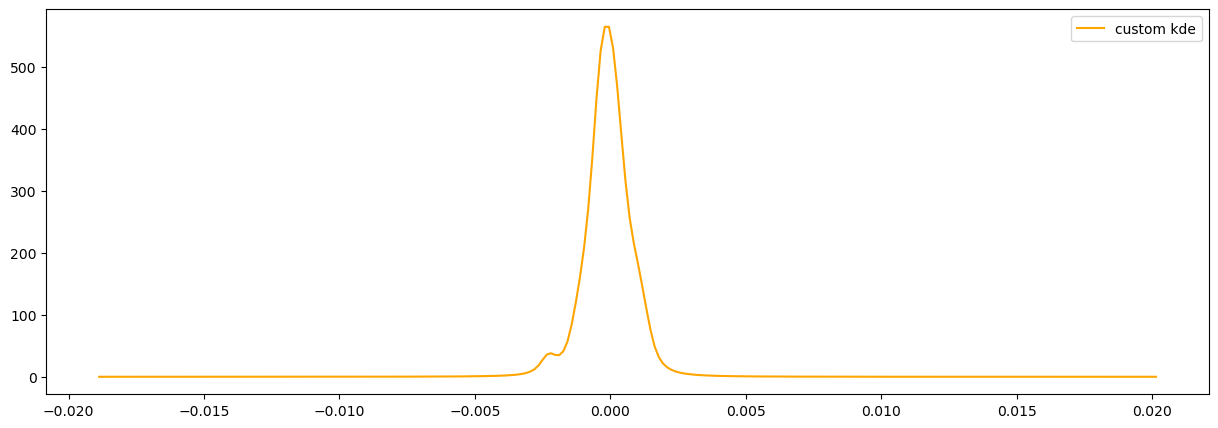

In [56]:
plt.figure(figsize=(15,5))

sns.lineplot(x=grid, y=density, color="orange", label="custom kde")

plt.show()

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


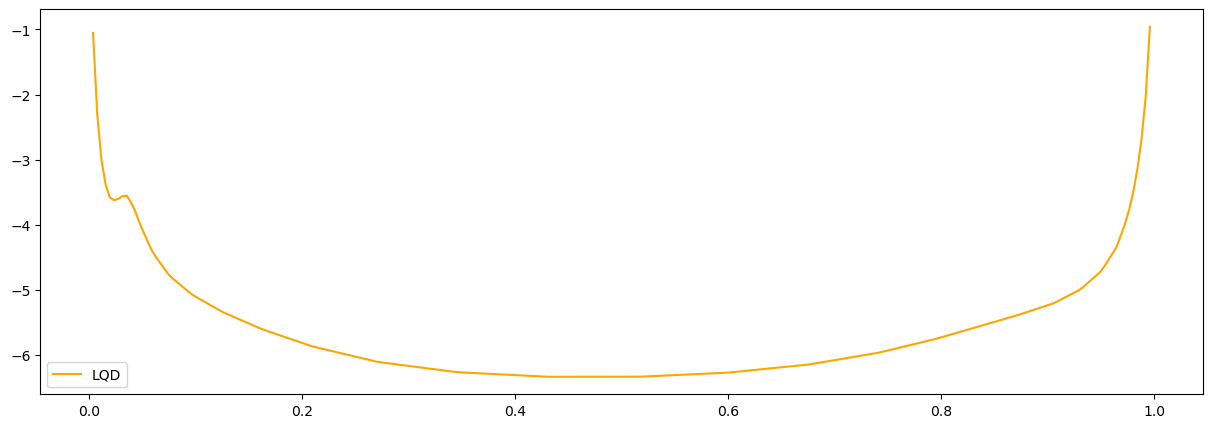

In [57]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [59]:
dSup, dens = lqd2dens(lqd, lqdSup, c=c, t0=t0_,dSup=grid)

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

Problem with LQD domain boundaries — resetting to default.
c not in lqdSup — resetting to closest value.


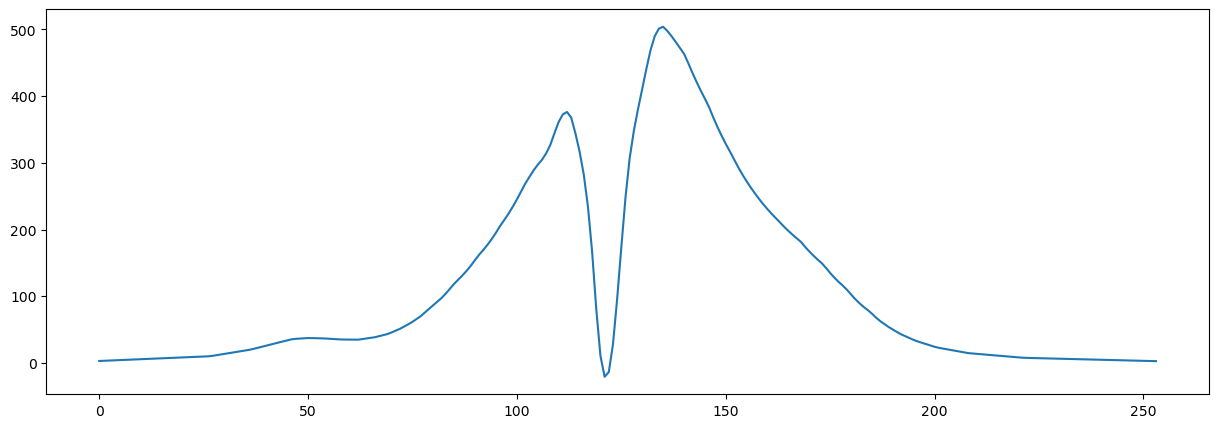

In [60]:
plt.figure(figsize=(15,5))

plt.plot(dens - density[1:-1])

plt.show()

# Versão no R - DJI_returns

In [111]:
df_r = pd.read_excel("../data/processed/r_transformation.xlsx")
df_r.sample(10)

,u,original_dens,backwards_dens
3346,-0.159268,7.010630e-01,0.701793
3533,-0.071689,4.814419e+00,4.815369
3202,-0.226708,1.365272e-03,0.000000
2903,-0.366741,5.759485e-17,0.000000
1791,-0.887530,1.186612e-16,0.000000
447,-1.516974,3.003455e-16,0.000000
4759,0.502491,0.000000e+00,0.000000
3874,0.088014,2.371724e-01,0.237371
3687,0.000435,7.005235e+00,7.003572
2073,-0.755459,2.205490e-16,0.000000


In [112]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.original_dens,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_r.u,
        y=df_r.backwards_dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

# Versão no R - Bovespa

In [21]:
i = 10
t = df.columns[i]
df_for_r = pd.DataFrame({'u': kde.grid, 'density': density})
df_for_r.to_excel("../data/interim/df_for_r.xlsx", index=False)

In [22]:
df_from_r = pd.read_excel(("../data/processed/r_transformation_bovespa_t.xlsx"))

In [23]:
fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=df_from_r.u,
        y=df_from_r.backwards_density,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

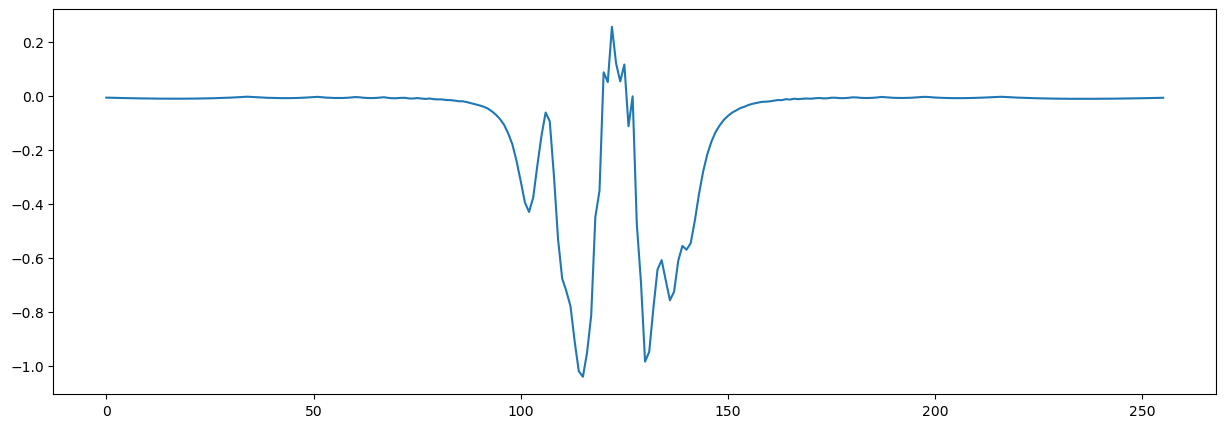

In [24]:
plt.figure(figsize=(15,5))

plt.plot(df_from_r.density - df_from_r.backwards_density)

plt.show()

# Ajusting LQDensity

In [38]:
# Dados
data_path = "../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df = pd.read_excel(returns_path, index_col="time")

i = 10
t = df.columns[i]
n = 256
Z_t = df.loc[:, t]

grid = np.linspace(df.min().min(), df.max().max(), n)

kde, density = fit_kde_model(Z_t, params, grid=grid)

Density does not integrate to 1 with tolerance 1e-5 - renormalizing now.


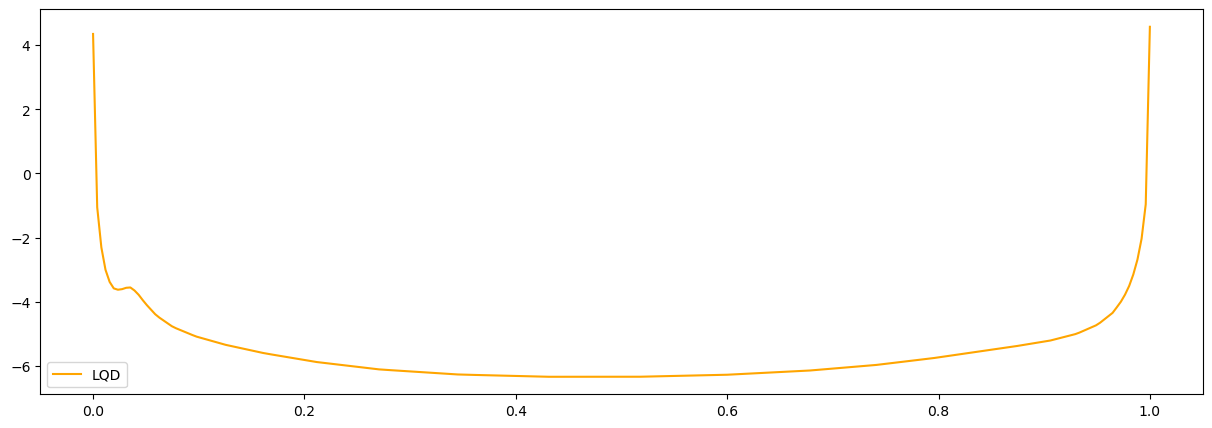

In [39]:
lqd_grid = np.linspace(0,1,n)
t0_ = grid[np.argmin(np.abs(grid))]
lqdSup, lqd, c = dens2lqd(
                        dens = density,
                        dSup = grid,
                        lqdSup = lqd_grid,
                        t0=t0_
                )

# lqdSup, lqd = lqdSup[1:-1], lqd[1:-1]

plt.figure(figsize=(15,5))

sns.lineplot(x=lqdSup, y=lqd, color="orange", label="LQD")

plt.show()

In [40]:
import numpy as np
import warnings
from scipy.interpolate import CubicSpline, interp1d
from scipy.integrate import quad


def trapz(x, y):
    """Trapezoidal integration (R trapzRcpp equivalent)."""
    return np.trapezoid(y, x)


def lqd2dens_test(
    lqd,
    lqdSup=None,
    dSup=None,
    t0=0.0,
    c=0.0,
    useSplines=True,
    cut=(0, 0),
    verbose=True
):
    """
    Convert log quantile density (LQD) to density.

    Parameters
    ----------
    lqd : array-like
        Log quantile density evaluated on lqdSup.
    lqdSup : array-like, optional
        Support of LQD domain; must start at 0 and end at 1.
    dSup : ignored (kept for API compatibility with R code).
    t0 : float
        Value such that target CDF satisfies F(t0) = c.
    c : float
        Value in lqdSup corresponding to F(t0).
    useSplines : bool
        Whether to use spline interpolation for numerical integration.
    cut : tuple (left, right)
        Number of grid points to cut from left and right boundaries.
    verbose : bool
        Print warnings/messages.

    Returns
    -------
    dict with keys:
        'dSup' : ndarray
            Density support grid.
        'dens' : ndarray
            Density values on dSup.
    """

    lqd = np.asarray(lqd, dtype=float)
    M = len(lqd)

    if lqdSup is None:
        lqdSup = np.linspace(0, 1, M)
    else:
        lqdSup = np.asarray(lqdSup, dtype=float)

    # Check support boundaries
    if not np.allclose([lqdSup.min(), lqdSup.max()], [0.0, 1.0]):
        warnings.warn(
            "Problem with support of the LQD domain's boundaries - resetting to default."
        )
        lqdSup = np.linspace(0, 1, M)

    # Detect infinite exp(lqd)
    r = np.where(np.isinf(np.exp(lqd)))[0]
    cut_left, cut_right = cut

    if len(r) > 0:
        mid = M // 2
        if np.any(r < mid):
            cut_left = max(cut_left, np.max(r[r < mid]) + 1)
        if np.any(r >= mid):
            cut_right = max(cut_right, M - np.min(r[r >= mid]))

    # Apply boundary cuts
    lqdSup = lqdSup[cut_left : M - cut_right]
    lqd = lqd[cut_left : M - cut_right]
    M = len(lqd)

    # Ensure c is in lqdSup
    if c not in lqdSup:
        if c < lqdSup[0] or c > lqdSup[-1]:
            raise ValueError("c is not contained within range of lqdSup after cutoff")

        if verbose:
            print("c is not equal to a value in lqdSup - resetting to closest value")

        c = lqdSup[np.argmin(np.abs(lqdSup - c))]

    c_ind = np.where(lqdSup == c)[0][0]

    # Construct density support via numerical integration
    if useSplines:
        # Natural cubic spline (R splinefun(method="natural"))
        lqd_sp = CubicSpline(lqdSup, lqd, bc_type="natural")

        def lqd_exp(t):
            return np.exp(lqd_sp(t))

        increments = np.zeros(M)
        for i in range(1, M):
            increments[i] = quad(lqd_exp, lqdSup[i - 1], lqdSup[i])[0]

        dtemp = (
            t0
            + np.cumsum(increments)
            - quad(lqd_exp, lqdSup[0], lqdSup[c_ind])[0]
        )

    else:
        dtemp = (
            t0
            + np.cumsum(
                np.concatenate([[0.0], np.diff(lqdSup) * np.exp(lqd[:-1])])
            )
            - trapz(lqdSup[: c_ind + 1], np.exp(lqd[: c_ind + 1]))
        )

    # Remove duplicates (mirrors R logic)
    mid = M // 2
    indL = np.zeros(M, dtype=bool)
    indR = np.zeros(M, dtype=bool)

    _, idxL = np.unique(dtemp[:mid][::-1], return_index=True)
    indL[:mid] = True
    indL[mid - 1 - idxL] = False

    _, idxR = np.unique(dtemp[mid:], return_index=True)
    indR[mid + idxR] = False
    indR[mid:] |= True

    keep = ~(indL | indR)

    dtemp = dtemp[keep]
    dens_temp = np.exp(-lqd[keep])

    # Interpolate to regular grid
    dSup = np.linspace(dtemp[0], dtemp[-1], M)
    interp_fun = interp1d(dtemp, dens_temp, kind="linear", fill_value="extrapolate")
    dens = interp_fun(dSup)

    # Normalize (accounting for cutoff)
    dens = dens / trapz(dSup, dens) * (lqdSup[-1] - lqdSup[0])

    return dSup, dens


In [43]:
dSup, dens = lqd2dens_test(
    lqd, 
    lqdSup, 
    c=c, 
    dSup=grid,
    t0 =  t0_
    )

fig = go.Figure()

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=grid,
        y=density,
        mode="lines",
        name="custom kde",
        line=dict(color="black")
    )
)

# Gaussian KDE
fig.add_trace(
    go.Scatter(
        x=dSup,
        y=dens,
        mode="lines",
        name="backwards custom kde",
        line=dict(color="red")
    )
)


fig.show()

c is not equal to a value in lqdSup - resetting to closest value
